In [99]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from warnings import filterwarnings
filterwarnings("ignore")
import scipy.stats as stats

In [15]:
df=pd.read_csv(r"C:\Users\sathish\Downloads\archive (6)\Salary_dataset.csv")
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [7]:
df.isnull().sum()

Unnamed: 0         0
YearsExperience    0
Salary             0
dtype: int64

In [19]:
df.drop('Unnamed: 0',axis=1,inplace=True)

In [27]:
df.duplicated().sum()

0

In [29]:
df.dtypes

YearsExperience    float64
Salary             float64
dtype: object

In [31]:
df.head(2)

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0


In [35]:
from sklearn.model_selection import train_test_split


In [41]:
X =df.drop('Salary',axis=1)
y = df['Salary']

In [43]:
X_train,X_test,y_train,y_test = train_test_split(X,y, random_state=42,test_size=0.33)

In [45]:
from sklearn.linear_model import LinearRegression

In [47]:
Lr = LinearRegression()

In [49]:
Lr.fit(X_train,y_train)

LinearRegression()

In [51]:
y_train_pred = Lr.predict(X_train)
y_test_pred =  Lr.predict(X_test)

In [53]:
pd.DataFrame({"Actual":y_test,"Predicted":y_test_pred})

,Actual,Predicted
27,112636.0,115815.307562
15,67939.0,71512.925348
23,113813.0,102618.853286
17,83089.0,75283.340855
8,64446.0,55488.659440
9,57190.0,60201.678825
28,122392.0,122413.534701
24,109432.0,107331.872670
12,56958.0,63029.490456
0,39344.0,35693.978025


In [75]:
from sklearn.metrics import mean_squared_error,accuracy_score,r2_score,adjusted_rand_score

In [89]:
print("Mean Squared Error",mean_squared_error(y_test,y_test_pred))
print("Root Mean Squared Error",np.sqrt(mean_squared_error(y_test,y_test_pred)))
print("R2",r2_score(y_test,y_test_pred))
print("adjusted r2",adjusted_rand_score(y_test,y_test_pred))

Mean Squared Error 35301898.887134835
Mean Squared Error 5941.540110706553
Mean Squared Error 0.9553063138044949
Mean Squared Error 1.0


In [125]:
print("Mean Squared Error",mean_squared_error(y_train,y_train_pred))
print("Root Mean Squared Error",np.sqrt(mean_squared_error(y_train,y_train_pred)))
print("R2",r2_score(y_train,y_train_pred))
print("Adjusted r2",adjusted_rand_score(y_train,y_train_pred))

Mean Squared Error 29793161.08242301
Root Mean Squared Error 5458.311193255933
R2 0.9549236946181227
Adjusted r2 1.0


In [127]:
residuals = y_test-y_test_pred

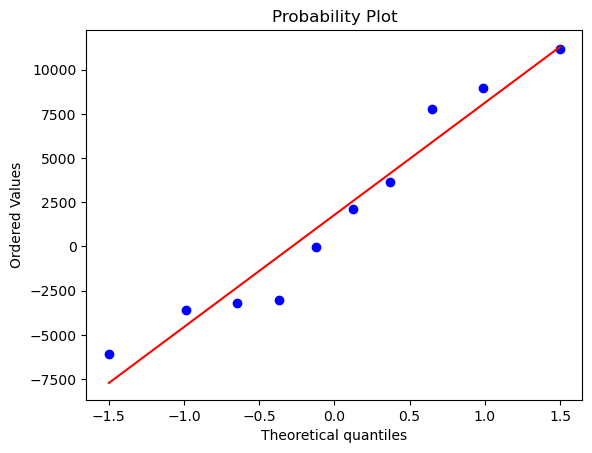

In [129]:
stats.probplot(residuals,plot=plt)
plt.show()

In [131]:
new_values = [[1.0],[2.8],[5.0],[4.2],[1.9],[7.0]]

In [133]:
predicted_salary=Lr.predict(new_values)

In [135]:
pd.DataFrame({"YearExp":new_values,"Predicted":predicted_salary})

,YearExp,Predicted
0,[1.0],33808.770271
1,[2.8],50775.640056
2,[5.0],71512.925348
3,[4.2],63972.094332
4,[1.9],42292.205164
5,[7.0],90365.002886


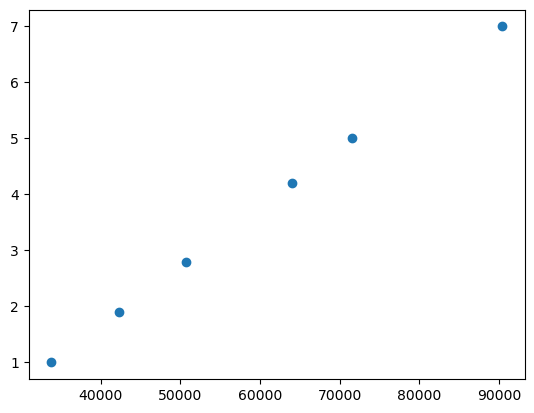

In [137]:
plt.scatter(x=predicted_salary,y=new_values)


In [142]:
#From Analysis
# Scatter Plot shows the linear Relationship
# R2_Score = 0.95 R2_score shows the 95% of relatiohsip variation
# The QQ plot show residuals normally distributed
# My Avg root mse is about 5500

Text(0.5, 1.0, 'Best Fit line')

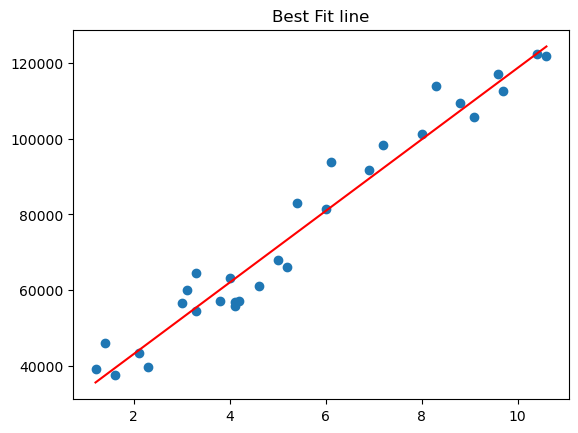

In [148]:
plt.scatter(X,y)
plt.plot(X,Lr.predict(X),color='red')
plt.title("Best Fit line")